# 🏆 实战挑战: 会员订阅对 LTV 的因果效应分析

## 1. 商业背景 (Business Context)
某电商平台推出了一项「付费会员计划」(Prime Membership)。管理层希望评估：**购买会员资格是否真的提升了用户的长期价值 (LTV)?**

*   **Treatment (干预)**: 用户是否订阅了会员 (`is_member`: 1=Yes, 0=No)
*   **Outcome (结果)**: 用户的生命周期价值 (`ltv`)
*   **Confounders (混淆变量)**: 
    *   `income_level`: 用户收入等级 (1-10)
    *   `shopping_freq`: 周均购物频次
    *   `age`: 用户年龄
    *   `activity_score`: 综合活跃度评分

## 2. 挑战目标 (Challenge Goal)
1.  **Naive Analysis**: 直接对比会员 vs 非会员的平均 LTV，计算差值。
2.  **Causal Analysis**: 使用你学过的因果推断方法 (PSM, IPW, DoWhy 等)，剔除混淆偏差，计算真实的 ATE (Average Treatment Effect)。

> 💡 **Hint**: 高价值用户本身就更容易购买会员 (Selection Bias)。如果不控制偏差，效果会被高估。

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 设置
%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 1. 加载数据
df = pd.read_csv('data/membership_ltv_data.csv')

# 2. 数据概览
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (10000, 7)


,user_id,income_level,shopping_freq,age,activity_score,is_member,ltv
0,0,5.99,1,36,2.93,1,1349.54
1,1,4.72,1,31,2.60,0,1001.47
2,2,6.30,1,57,1.61,0,1140.03
3,3,8.05,4,39,3.93,1,1739.61
4,4,4.53,4,44,3.32,1,1386.24


## 3. Start Your Analysis Here 👇
请从这里开始你的代码。你可以自由选择方法 (PSM, DoWhy, Regression Adjustment...)。

<Axes: >

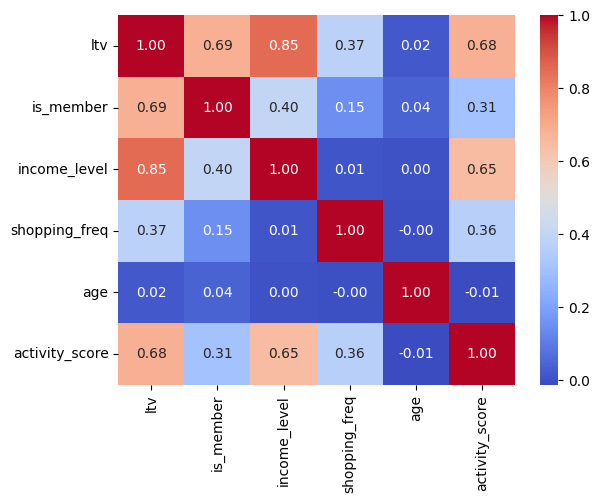

In [2]:
# 方法决策：横截面数据，无时间，因此选择PSM/IPW/IV 

# 0. 相关性热力图
corr = df[['ltv','is_member','income_level','shopping_freq','age','activity_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

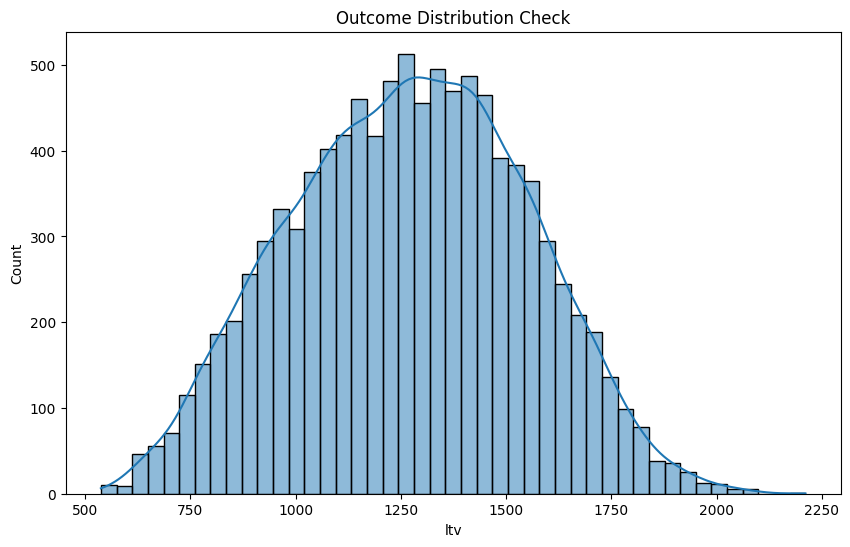

Skewness: -0.02


In [3]:
# 初步结论1：age与其他变量的相关性极小，可以初步排除，属于噪声
# 初步结论2：ltv 与其他变量相关性排序 income_level>is_member>activity_score>shopping_freq>age
# 初步结论3：income_level 与 activity_score 高度相关0.65 可能属于内生变量
# 初步结论4：is_member 与income_level也有较高相关 0.40
# 初步结论5：activity_score与shopping_freq也有较高相关 0.36

# 检查数据分布

# 分布检查代码 (Distribution Check)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 绘制直方图 + KDE 曲线
plt.figure(figsize=(10, 6))
sns.histplot(df['ltv'], kde=True)
plt.title('Outcome Distribution Check')
plt.show()

# 2. 偏度检查 (Skewness)
skewness = df['ltv'].skew()
print(f"Skewness: {skewness:.2f}")
if skewness > 1:
    print("Tip: 右偏严重，建议尝试 np.log1p(Y) 变换")

In [4]:
# 因果关系假设：ltv ~ [is_member ~ income_level] + [activity_score ~ shopping_freq] + age
# # 使用 graphviz 简单绘制
# from graphviz import Digraph
# dot = Digraph()

# # 1. 定义节点
# dot.node('T', 'is_member (Treatment)', shape='box', style='filled', color='lightblue')
# dot.node('Y', 'ltv (Outcome)', shape='box', style='filled', color='lightgreen')

# # 2. 定义混淆变量节点
# confounders = ['income_level', 'shopping_freq', 'age', 'activity_score']
# for c in confounders:
#     dot.node(c, c)

# # 3. 添加连线 (Confounder -> T, Confounder -> Y)
# # 同时也画出关键的 T -> Y 连线
# dot.edge('T', 'Y', label='Causal Effect?')

# for c in confounders:
#     dot.edge(c, 'T') # 混淆变量影响干预 (e.g. 有钱人更爱买会员)
#     dot.edge(c, 'Y') # 混淆变量影响结果 (e.g. 有钱人LTV本来就高)

# dot


In [15]:
from linearmodels.iv import IV2SLS

# 正确写法：把内生变量和工具变量分别合并在一起
# Exog (外生变量): 1 (常数项) + age
# Endog (内生变量): is_member + activity_score
# Instr (工具变量): income_level + shopping_freq

iv_model = IV2SLS.from_formula(
    'ltv ~ 1 + age + [is_member + activity_score ~ income_level + shopping_freq]', 
    data=df
).fit()

print(iv_model)


                          IV-2SLS Estimation Summary                          
Dep. Variable:                    ltv   R-squared:                      0.0864
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0861
No. Observations:               10000   F-statistic:                 1.222e+04
Date:                Tue, Feb 17 2026   P-value (F-stat)                0.0000
Time:                        18:19:33   Distribution:                  chi2(3)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
Intercept          551.63     16.229     33.991     0.0000      519.82      583.44
age               -0.9775     0.3424

In [17]:
# 拆分1：is_member 与 income_level 的因果推断

import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

model = smf.ols("is_member ~ income_level", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              is_member   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     1905.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:21:35   Log-Likelihood:                -6221.2
No. Observations:               10000   AIC:                         1.245e+04
Df Residuals:                    9998   BIC:                         1.246e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0853      0.012      6.875   

In [21]:
# 简单的 OLS 多元回归 (控制混淆变量)
# 这才是这种数据结构下的标准解法
reg_model = smf.ols(
    formula='ltv ~ is_member + activity_score + income_level + shopping_freq + age', 
    data=df
).fit()
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ltv   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                 5.863e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:24:52   Log-Likelihood:                -53382.
No. Observations:               10000   AIC:                         1.068e+05
Df Residuals:                    9994   BIC:                         1.068e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        493.7528      2.460    200.

In [25]:
# 模型2：精简版 (只保留显著的混淆变量)
reg_model_2 = smf.ols(
    formula='ltv ~ is_member + income_level + shopping_freq', 
    data=df
).fit()
print(reg_model_2.summary())

# 比较两个模型的 is_member 系数
effect_1 = reg_model.params['is_member']
effect_2 = reg_model_2.params['is_member']

print(f"全模型效应值: {effect_1:.2f}")
print(f"精简模型效应值: {effect_2:.2f}")
print(f"偏差百分比: {(effect_2 - effect_1) / effect_1 * 100:.2f}%")


                            OLS Regression Results                            
Dep. Variable:                    ltv   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                 9.773e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:25:06   Log-Likelihood:                -53382.
No. Observations:               10000   AIC:                         1.068e+05
Df Residuals:                    9996   BIC:                         1.068e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       495.1736      1.632    303.462

In [27]:
# 再直接用PSM算算除了is_member以外的概率……
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import pandas as pd
df['user_id'] = df['user_id'].astype(str)
X = df.drop(columns=['is_member', 'ltv','user_id','income_level','activity_score'])
y = df['is_member']
# 1. 计算 Propensity Score
lr = LogisticRegression()
lr.fit(X, y)
df['ps_score'] = lr.predict_proba(X)[:, 1]

# 2. 执行匹配 (简单版 - 1对1匹配)
treated = df[df['is_member'] == 1]
control = df[df['is_member'] == 0]

# 在 Control 组中找 Treated 组的邻居
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['ps_score']])
distances, indices = nn.kneighbors(treated[['ps_score']])

# 获取匹配后的 Control 组数据
matched_control = control.iloc[indices.flatten()]

# # 3. 计算 ATE (Average Treatment Effect)
# ate = treated['Spend'].mean() - matched_control['Spend'].mean()
# print(f"PSM Estimated Effect: {ate}")

# df
# treated
# control
matched_control.describe(include='all')


,user_id,income_level,shopping_freq,age,activity_score,is_member,ltv,ps_score,ipw_weight
count,5900,5900.000000,5900.000000,5900.000000,5900.000000,5900.0,5900.000000,5900.000000,5900.000000
unique,707,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,4795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.267515,7.817288,24.348814,4.081415,0.0,1219.013100,0.489722,3.018860
std,NaN,2.023116,2.396282,7.497981,0.908359,0.0,160.733235,0.133733,1.359235
min,NaN,1.000000,0.000000,18.000000,-1.910000,0.0,559.190000,0.092738,1.182693
25%,NaN,2.470000,9.000000,21.000000,4.070000,0.0,1200.470000,0.549438,2.637196
50%,NaN,2.470000,9.000000,21.000000,4.070000,0.0,1200.470000,0.549438,2.637196
75%,NaN,2.470000,9.000000,21.000000,4.070000,0.0,1200.470000,0.549438,2.637196


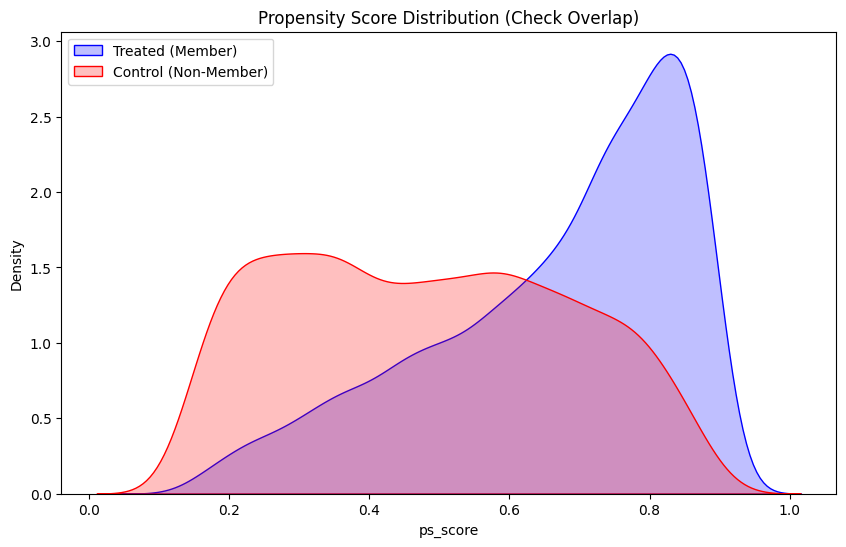

被重复匹配最多的 Control 用户：
user_id
4855    45
8997    38
6169    34
7955    33
5549    27
Name: count, dtype: int64


In [9]:
# 1. 绘制 Propensity Score 分布 (查看 Common Support)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['is_member']==1]['ps_score'], label='Treated (Member)', fill=True, color='blue')
sns.kdeplot(df[df['is_member']==0]['ps_score'], label='Control (Non-Member)', fill=True, color='red')
plt.title('Propensity Score Distribution (Check Overlap)')
plt.legend()
plt.show()

# 检查一下那 3 个“天选之子”是谁
print("被重复匹配最多的 Control 用户：")
print(matched_control['user_id'].value_counts().head())


In [28]:
# 1. 找出 Common Support 的范围
min_ps_control = df[df['is_member']==0]['ps_score'].min()
max_ps_control = df[df['is_member']==0]['ps_score'].max()

print(f"Non-Member PS Range: [{min_ps_control:.4f}, {max_ps_control:.4f}]")

# 2. 截断：只保留在这个范围内的 Member
df_trimmed = df[
    (df['ps_score'] >= min_ps_control) & 
    (df['ps_score'] <= max_ps_control)
]

print(f"Trimmed Data Shape: {df_trimmed.shape}")

# 3. 在截断后的数据上跑 OLS (最稳健)
model_trimmed = smf.ols('ltv ~ is_member + income_level + shopping_freq + age + activity_score', data=df_trimmed).fit()
print(model_trimmed.summary())


Non-Member PS Range: [0.0927, 0.5494]
Trimmed Data Shape: (5121, 9)
                            OLS Regression Results                            
Dep. Variable:                    ltv   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                 1.326e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:31:34   Log-Likelihood:                -27358.
No. Observations:                5121   AIC:                         5.473e+04
Df Residuals:                    5115   BIC:                         5.477e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [29]:
import dowhy
from dowhy import CausalModel

# 1. 定义因果模型 (Define Causal Model)
# 明确告诉 DoWhy：Treatment 是会员，Outcome 是 LTV，其他是混淆变量
model = CausalModel(
    data=df,
    treatment='is_member',
    outcome='ltv',
    common_causes=['income_level', 'shopping_freq', 'age', 'activity_score']
)

# 2. 识别与估计 (Identify & Estimate)
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

# 使用简单的线性回归 (Backdoor.linear_regression)
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print(f"DoWhy 初始估计值: {estimate.value}")

# 3. 稳健性检验 (Refutation Tests) - 见证奇迹的时刻

print("\n----------------------------------------------------------------")
print("测试 1: 安慰剂检验 (Placebo Treatment)")
print("期待结果: New Effect 应该接近 0")
refute_placebo = model.refute_estimate(
    identified_estimand, 
    estimate,
    method_name="placebo_treatment_refuter"
)
print(refute_placebo)

print("\n----------------------------------------------------------------")
print("测试 2: 添加随机混淆变量 (Random Common Cause)")
print("期待结果: New Effect 应该接近初始估计值 (不变)")
refute_rcc = model.refute_estimate(
    identified_estimand, 
    estimate,
    method_name="random_common_cause"
)
print(refute_rcc)


DoWhy 初始估计值: 201.4629671780399

----------------------------------------------------------------
测试 1: 安慰剂检验 (Placebo Treatment)
期待结果: New Effect 应该接近 0
Refute: Use a Placebo Treatment
Estimated effect:201.4629671780399
New effect:0.10429449612672215
p value:0.94


----------------------------------------------------------------
测试 2: 添加随机混淆变量 (Random Common Cause)
期待结果: New Effect 应该接近初始估计值 (不变)
Refute: Add a random common cause
Estimated effect:201.4629671780399
New effect:201.46227496686532
p value:0.84

